In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
#Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#Dataset Information
print("Shape:", df.shape)

df.info()

df.describe(include='all')

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [4]:
#Missing Values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

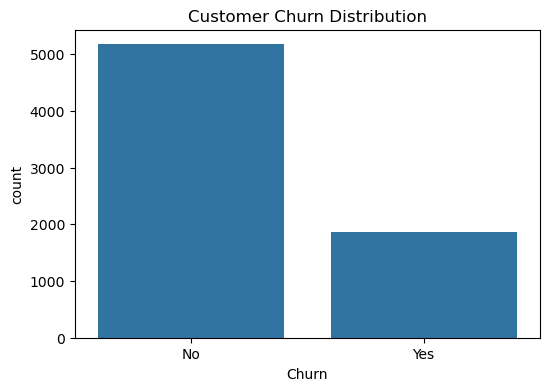

In [5]:
#Churn Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

In [6]:
#Class Percentage
churn_percentage = df['Churn'].value_counts(normalize=True)*100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [7]:
#Preprocessing
#Remove Customer ID
df.drop(
    'customerID',
    axis=1,
    inplace=True
)

In [8]:
#Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors='coerce'
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [9]:
#Encode Target
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [10]:
#One Hot Encoding
df = pd.get_dummies(
    df,
    drop_first=True
)

In [11]:
#Features and Target
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

In [12]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [13]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:
#MODEL 1: Logistic Regression
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
#Predictions
y_pred_log = log_model.predict(
    X_test
)

y_prob_log = log_model.predict_proba(
    X_test
)[:,1]

In [16]:
#Metrics
print("Accuracy:",
      accuracy_score(y_test,y_pred_log))

print("Precision:",
      precision_score(y_test,y_pred_log))

print("Recall:",
      recall_score(y_test,y_pred_log))

print("F1 Score:",
      f1_score(y_test,y_pred_log))

Accuracy: 0.8069552874378992
Precision: 0.6583850931677019
Recall: 0.5668449197860963
F1 Score: 0.6091954022988506


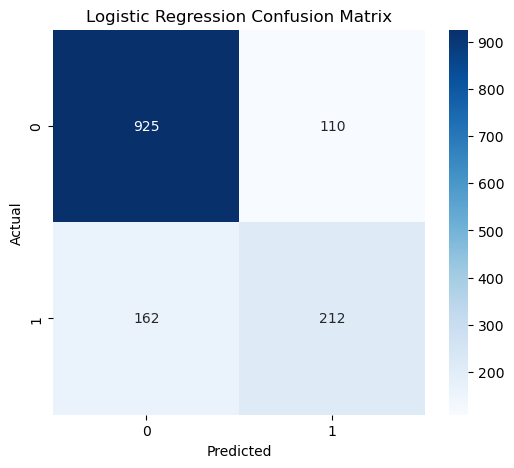

In [17]:
#Confusion Matrix
cm_log = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [18]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [ ]:
# #True Positive (TP)
# A True Positive occurs when the model correctly predicts that a customer will churn, and the customer actually churns.
# Example:
# A customer is predicted to leave the company, and the customer actually leaves.

# This is a correct prediction and is beneficial because the company can take preventive actions before losing the customer.

# #True Negative (TN)
# A True Negative occurs when the model correctly predicts that a customer will not churn, and the customer actually remains with the company.
# Example:
# A customer is predicted to stay, and the customer continues using the service.
# This is also a correct prediction.

# #False Positive (FP)
# A False Positive occurs when the model predicts that a customer will churn, but the customer actually stays.
# Example:
# The company may offer discounts or retention campaigns to a customer who was never going to leave.
# Although this may increase marketing costs, the customer is still retained.

# #False Negative (FN)
# A False Negative occurs when the model predicts that a customer will not churn, but the customer actually leaves.
# Example:
# A customer who is likely to leave is not identified by the model and receives no retention effort.
# This is generally the most costly error in customer churn prediction because it can result in loss of customers and revenue.
    

In [ ]:
# #Why Accuracy Alone is Insufficient
# Accuracy measures the overall percentage of correct predictions made by a model.

# Accuracy=TP+TN/TP+TN+FP+FN
# However, accuracy alone can be misleading when dealing with imbalanced datasets such as customer churn prediction.
# In the Telco Customer Churn dataset, the number of customers who do not churn is significantly higher than the number of customers who churn. A model could predict "No Churn" for most customers and still achieve a high accuracy score while failing to identify many actual churners.
# For example:
# Logistic Regression Accuracy = 80.70%
# Balanced Logistic Regression Accuracy = 73.88%
# Although Logistic Regression has higher accuracy, Balanced Logistic Regression achieves a much higher Recall (78.07%) compared to Logistic Regression (56.68%).
# This means the Balanced Logistic Regression model identifies many more customers who are likely to leave, which is more valuable from a business perspective.
# Therefore, additional metrics such as:
# Precision
# Recall
# F1 Score
# ROC-AUC
# must be considered along with Accuracy to properly evaluate classification models.
# For customer churn prediction, Recall and F1 Score are especially important because missing a churn customer (False Negative) can directly impact customer retention and business revenue.

In [ ]:
# 1. Which Metric is More Important for Medical Diagnosis?

# In medical diagnosis, Recall is usually the most important metric.

# Reason:
# Recall measures how many actual positive cases are correctly identified.

# Recall=TP/TP+FN
# In healthcare, a False Negative can be very dangerous.
# Example:
# Suppose a patient has cancer.
# Actual: Cancer
# Predicted: No Cancer
# This is a False Negative.
# If the disease is not detected, treatment may be delayed, leading to serious consequences.
# Therefore, medical diagnosis systems prioritize high Recall to ensure that as many diseased patients as possible are identified.

# 2. What Happens if Recall is Low?

# Low Recall means the model is missing many actual positive cases.
# A low Recall indicates a high number of False Negatives.
# Example in Customer Churn:
# Customer is likely to leave.
# Model predicts customer will stay.
# The company loses the opportunity to retain that customer.
    
# Example in Medical Diagnosis:
# Patient has a disease.
# Model predicts healthy.
# The disease remains untreated.
    
# Effects of Low Recall:
# More False Negatives
# Important cases are missed
# Reduced reliability of the model
# Potential financial or health-related losses
# Therefore, when missing positive cases is costly, Recall should be maximized.

# 3. Why is F1-Score Preferred for Imbalanced Data?

# F1-Score is preferred because it considers both Precision and Recall.

# F1=2×Precision*Recall/Precision+Recall

# Problem with Accuracy
# Consider a dataset with:
# 950 Non-Churn customers
# 50 Churn customers

# A model predicts every customer as "Non-Churn".

# Accuracy:950/1000 = 95%

# The model achieves 95% Accuracy but fails to identify any churn customer.

# This makes Accuracy misleading for imbalanced datasets.

# Why F1-Score Helps

# F1-Score balances:

# Precision (How many predicted positives are correct)
# Recall (How many actual positives are found)

# A high F1-Score indicates that the model:

# Correctly identifies positive cases
# Minimizes both False Positives and False Negatives

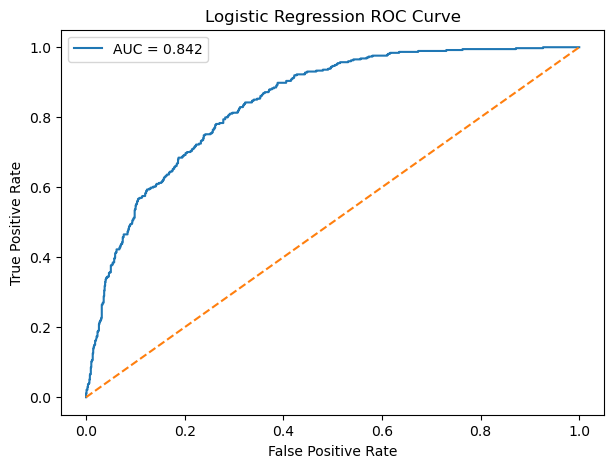

AUC Score: 0.8415846443979436


In [19]:
#ROC Curve + AUC
auc_log = roc_auc_score(
    y_test,
    y_prob_log
)

fpr_log,tpr_log,_ = roc_curve(
    y_test,
    y_prob_log
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"AUC = {auc_log:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "Logistic Regression ROC Curve"
)

plt.legend()

plt.show()

print("AUC Score:",auc_log)

In [20]:
#MODEL 2: Balanced Logistic Regression
balanced_model = LogisticRegression(

    class_weight='balanced',

    max_iter=1000
)

balanced_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
#Predictions
y_pred_bal = balanced_model.predict(
    X_test
)

y_prob_bal = balanced_model.predict_proba(
    X_test
)[:,1]

In [22]:
#MODEL 3: Decision Tree Classifier
dt_model = DecisionTreeClassifier(

    max_depth=5,

    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
#Predictions
y_pred_dt = dt_model.predict(
    X_test
)

y_prob_dt = dt_model.predict_proba(
    X_test
)[:,1]

In [24]:
#Decision Tree Metrics
print("Accuracy:",
      accuracy_score(y_test,y_pred_dt))

print("Precision:",
      precision_score(y_test,y_pred_dt))

print("Recall:",
      recall_score(y_test,y_pred_dt))

print("F1 Score:",
      f1_score(y_test,y_pred_dt))

Accuracy: 0.794180269694819
Precision: 0.6296296296296297
Recall: 0.5454545454545454
F1 Score: 0.5845272206303725


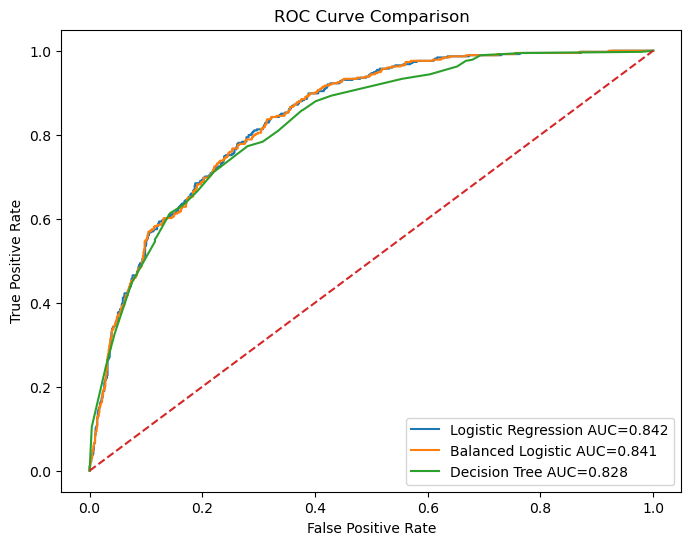

In [25]:
#ROC Comparision (Important)
auc_bal = roc_auc_score(
    y_test,
    y_prob_bal
)

auc_dt = roc_auc_score(
    y_test,
    y_prob_dt
)

fpr_bal,tpr_bal,_ = roc_curve(
    y_test,
    y_prob_bal
)

fpr_dt,tpr_dt,_ = roc_curve(
    y_test,
    y_prob_dt
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression AUC={auc_log:.3f}"
)

plt.plot(
    fpr_bal,
    tpr_bal,
    label=f"Balanced Logistic AUC={auc_bal:.3f}"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree AUC={auc_dt:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.show()

In [26]:
#Model Comparison Table
comparison_df = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Balanced Logistic Regression",

        "Decision Tree"
    ],

    "Accuracy":[

        accuracy_score(y_test,y_pred_log),

        accuracy_score(y_test,y_pred_bal),

        accuracy_score(y_test,y_pred_dt)
    ],

    "Precision":[

        precision_score(y_test,y_pred_log),

        precision_score(y_test,y_pred_bal),

        precision_score(y_test,y_pred_dt)
    ],

    "Recall":[

        recall_score(y_test,y_pred_log),

        recall_score(y_test,y_pred_bal),

        recall_score(y_test,y_pred_dt)
    ],

    "F1 Score":[

        f1_score(y_test,y_pred_log),

        f1_score(y_test,y_pred_bal),

        f1_score(y_test,y_pred_dt)
    ],

    "AUC":[

        auc_log,

        auc_bal,

        auc_dt
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841585
1,Balanced Logistic Regression,0.738822,0.505190,0.780749,0.613445,0.841233
2,Decision Tree,0.794180,0.629630,0.545455,0.584527,0.828358


In [27]:
#Save Comparison Results
comparison_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

In [28]:
#Save Best Model
joblib.dump(
    balanced_model,
    "telco_customer_churn_model.joblib"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully
